## Testing Data Configs
This notebook tests different combinations of dataset config parameters (background subtraction, normalisation, resizing) to find the optimal config for the TouchFL dataset. This config will be saved in the configs directory for use in model building.

We will use the 'object' label for our classification model.

In [1]:
# Allow imports from the parent directory
import sys
import os
module_path = os.path.abspath(os.path.join('..'))
sys.path.append(module_path)

In [2]:
# Imports
import json
import torch
from torch import optim
import torch.nn as nn
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from data.builder import get_dataloaders
from models.baseline import BaselineCNNModel
from train_eval import train_classifier, eval_classifier

In [3]:
# Setup cuda
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device

device(type='cuda')

In [4]:
# Set random seed for reproducibility
torch.manual_seed(129)

### Load Data

In [5]:
# Get default data config from json file
with open('../configs/default_data_config.json', 'r', encoding='utf-8') as f:
    data_config = json.load(f)

In [6]:
# Create a list of data configs for each fold
# Start with default config and modify the fold-specific parameters for each fold
data_configs = [data_config.copy() for _ in range(8)]

In [7]:
# Update norm cache path for each fold as default path assumes we are in the root directory
# We are in the notebooks directory so we need to go up one level to access the cache file
for config in data_configs:
    config['norm_cache_path'] = '../configs/norm_cache.json'

In [8]:
# Set the path name for the baseline background image
BG_PATH = '../data/baseline.jpg'

In [9]:
# Define the different combinations of data config parameters to test
changes = [{'transform_name': 'pad_224', 'norm_type': None, 'bg_path': None},
           {'transform_name': 'pad_224', 'norm_type': None, 'bg_path': BG_PATH},
           {'transform_name': 'pad_224', 'norm_type': 'dataset', 'bg_path': None},
           {'transform_name': 'pad_224', 'norm_type': 'dataset', 'bg_path': BG_PATH},
           {'transform_name': 'center_crop_224', 'norm_type': None, 'bg_path': None},
           {'transform_name': 'center_crop_224', 'norm_type': None, 'bg_path': BG_PATH},
           {'transform_name': 'center_crop_224', 'norm_type': 'dataset', 'bg_path': None},
           {'transform_name': 'center_crop_224', 'norm_type': 'dataset', 'bg_path': BG_PATH},]

In [10]:
# Define the titles for each data config combination
titles = ['pad_224_no_norm_no_bg',
          'pad_224_no_norm_bg',
          'pad_224_dataset_norm_no_bg',
          'pad_224_dataset_norm_bg',
          'center_crop_224_no_norm_no_bg',
          'center_crop_224_no_norm_bg',
          'center_crop_224_dataset_norm_no_bg',
          'center_crop_224_dataset_norm_bg']

In [11]:
# Update the data configs with the different combinations of parameters
for i in range(len(data_configs)):
    data_configs[i].update(changes[i])

In [12]:
# Get (dataloaders, label_info) tuples for each fold using the different data configs
data = [get_dataloaders(cfg) for cfg in data_configs]
# Split into dataloaders and label_info lists for easier access
dataloaders = [item[0] for item in data]
label_infos = [item[1] for item in data]

Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found but config does not match.
Calculating normalisation stats...
Normalisation stats calculated and saved to cache.
Dataframe split into following sizes:
Train: 36240, Val: 7800, Test: 7800
Norm cache found b

In [13]:
# Get the object labels from the first label_info (same for all)
object_labels = label_infos[0]['label2idx']['object'].keys()
# Confirm number of classes
num_classes = len(object_labels)
num_classes

6

### Training

In [14]:
# Define the model training configuration
model_config = {
    'optimizer': optim.Adam,
    'learning_rate': 0.001,
    'num_epochs': 5,
    'checkpoint_dir': '../checkpoints',
    'model_title': 'test_data_configs',
}

In [15]:
# Create a list of model configs for each fold
model_configs = [model_config.copy() for _ in range(8)]

In [16]:
# Update the model configs with the different titles for each fold
for i in range(len(model_configs)):
    model_configs[i]['model_title'] = titles[i]

In [17]:
# Train and validate the model for each fold using the corresponding dataloaders
models = []
histories = []

for i in range(len(dataloaders)):
    # Re-initialize the model for each fold
    model = BaselineCNNModel(num_classes=num_classes)
    # Train the model and save the history
    model, history = train_classifier(model=model, 
                                    device=device, 
                                    train_loader=dataloaders[i]['train'], 
                                    val_loader=dataloaders[i]['val'], 
                                    target_label='object',
                                    config=model_configs[i])
    models.append(model)
    histories.append(history)

Starting training of pad_224_no_norm_no_bg on device: cuda
Epoch 1/5
Train Loss: 0.9512, Train Acc: 61.37%
Val Loss: 1.0566, Val Acc: 65.35%
Epoch 2/5
Train Loss: 0.3301, Train Acc: 88.18%
Val Loss: 1.0080, Val Acc: 68.51%
Epoch 3/5
Train Loss: 0.1535, Train Acc: 94.68%
Val Loss: 0.8681, Val Acc: 76.51%
Epoch 4/5
Train Loss: 0.1035, Train Acc: 96.38%
Val Loss: 0.8757, Val Acc: 78.50%
Epoch 5/5
Train Loss: 0.0907, Train Acc: 96.97%
Val Loss: 0.9397, Val Acc: 79.35%
Starting training of pad_224_no_norm_bg on device: cuda
Epoch 1/5
Train Loss: 0.2982, Train Acc: 88.18%
Val Loss: 0.6446, Val Acc: 84.08%
Epoch 2/5
Train Loss: 0.0272, Train Acc: 99.16%
Val Loss: 0.9367, Val Acc: 83.42%
Epoch 3/5
Train Loss: 0.0165, Train Acc: 99.48%
Val Loss: 0.7159, Val Acc: 86.51%
Epoch 4/5
Train Loss: 0.0163, Train Acc: 99.54%
Val Loss: 1.1469, Val Acc: 80.82%
Epoch 5/5
Train Loss: 0.0142, Train Acc: 99.60%
Val Loss: 0.8582, Val Acc: 85.24%
Starting training of pad_224_dataset_norm_no_bg on device: cuda
E

In [18]:
# Convert histories to Pandas DataFrame
# Columns should start from 1 instead of 0 to match epoch numbers
histories_df = pd.DataFrame(histories, 
                            index=titles, 
                            columns=[f'epoch_{i+1}' for i in range(len(histories[0]))])
# Save Dataframe to CSV file
histories_df.to_csv('../results/test_data_configs/histories.csv', index=True)

In [19]:
histories_df

,epoch_1,epoch_2,epoch_3,epoch_4,epoch_5
pad_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 0.9512320601061605,...","{'epoch': 2, 'train_loss': 0.33009249026848486...","{'epoch': 3, 'train_loss': 0.1535027454564445,...","{'epoch': 4, 'train_loss': 0.10351250584862817...","{'epoch': 5, 'train_loss': 0.09070303771601265..."
pad_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.2982165304649439,...","{'epoch': 2, 'train_loss': 0.02715261423758707...","{'epoch': 3, 'train_loss': 0.01646553419670689...","{'epoch': 4, 'train_loss': 0.01634320032637916...","{'epoch': 5, 'train_loss': 0.01417240941341417..."
pad_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.6605346708181203,...","{'epoch': 2, 'train_loss': 0.14013955217357874...","{'epoch': 3, 'train_loss': 0.08015987548454347...","{'epoch': 4, 'train_loss': 0.05432195793036632...","{'epoch': 5, 'train_loss': 0.04810301036697143..."
pad_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.16048062018242149...","{'epoch': 2, 'train_loss': 0.02397386264335077...","{'epoch': 3, 'train_loss': 0.00721965395929166...","{'epoch': 4, 'train_loss': 0.02645153219727712...","{'epoch': 5, 'train_loss': 8.104960974701246e-..."
center_crop_224_no_norm_no_bg,"{'epoch': 1, 'train_loss': 1.1701049325824942,...","{'epoch': 2, 'train_loss': 0.3890068510519332,...","{'epoch': 3, 'train_loss': 0.24361825887103947...","{'epoch': 4, 'train_loss': 0.1606924454184267,...","{'epoch': 5, 'train_loss': 0.13266978466953994..."
center_crop_224_no_norm_bg,"{'epoch': 1, 'train_loss': 0.306255288069471, ...","{'epoch': 2, 'train_loss': 0.03906854629494228...","{'epoch': 3, 'train_loss': 0.02595353009499036...","{'epoch': 4, 'train_loss': 0.01528163266929483...","{'epoch': 5, 'train_loss': 0.0249996586200377,..."
center_crop_224_dataset_norm_no_bg,"{'epoch': 1, 'train_loss': 0.48821921049825195...","{'epoch': 2, 'train_loss': 0.10956455469191065...","{'epoch': 3, 'train_loss': 0.07754900861547526...","{'epoch': 4, 'train_loss': 0.05157632958878738...","{'epoch': 5, 'train_loss': 0.04167902569917998..."
center_crop_224_dataset_norm_bg,"{'epoch': 1, 'train_loss': 0.1942276384026229,...","{'epoch': 2, 'train_loss': 0.03845811612431590...","{'epoch': 3, 'train_loss': 0.01967528765196493...","{'epoch': 4, 'train_loss': 0.02025463010433301...","{'epoch': 5, 'train_loss': 0.01680018630779901..."


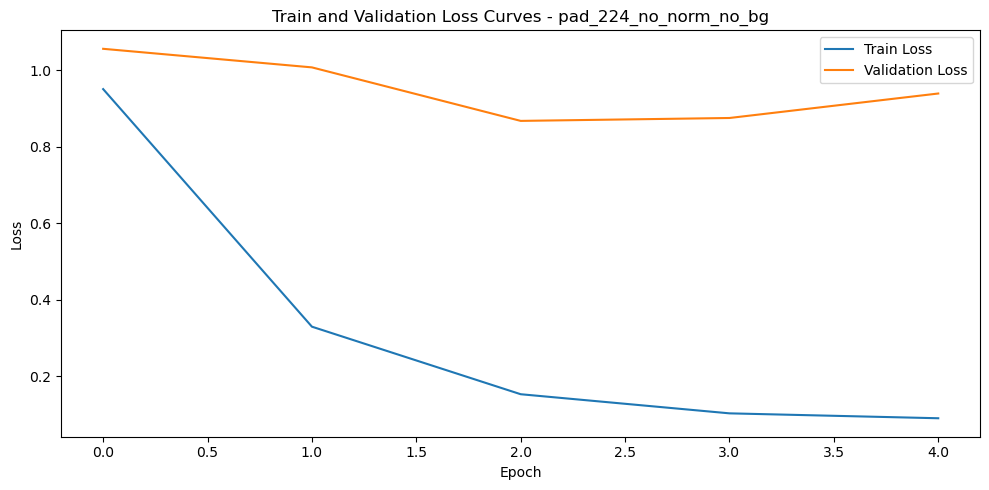

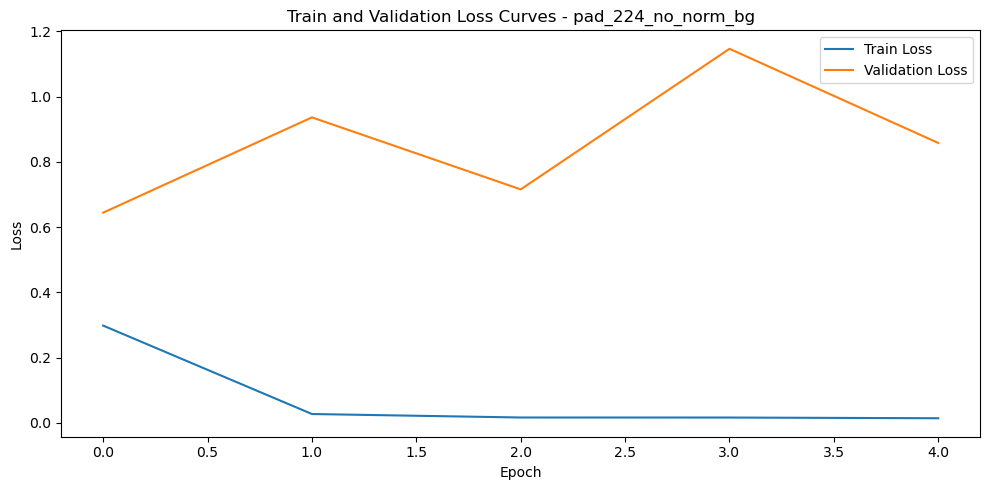

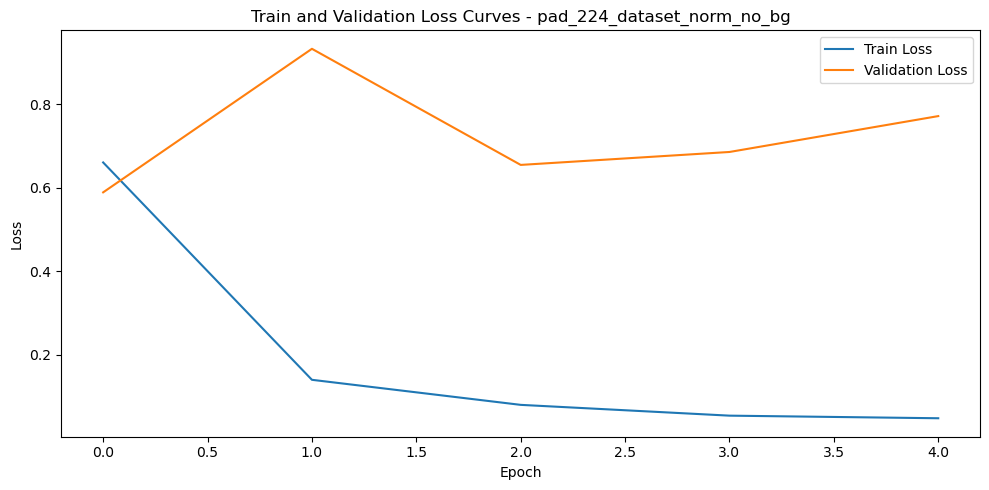

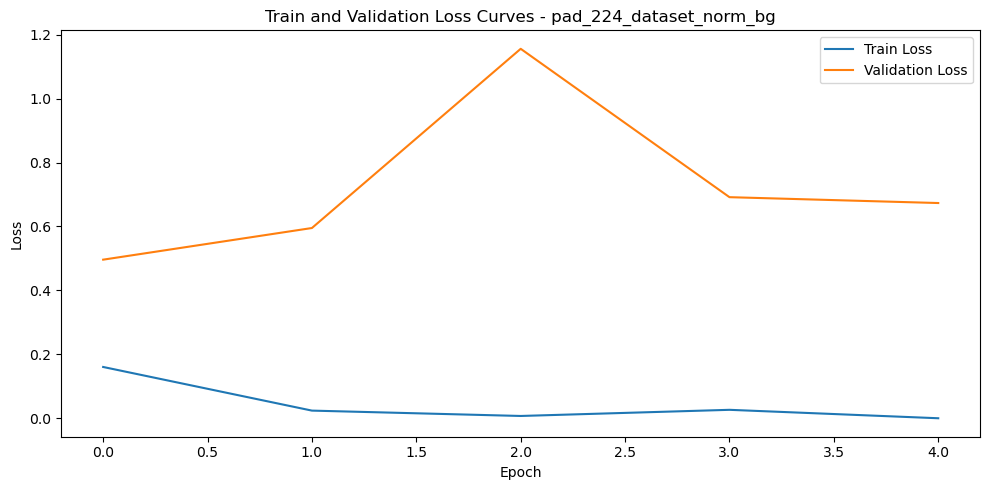

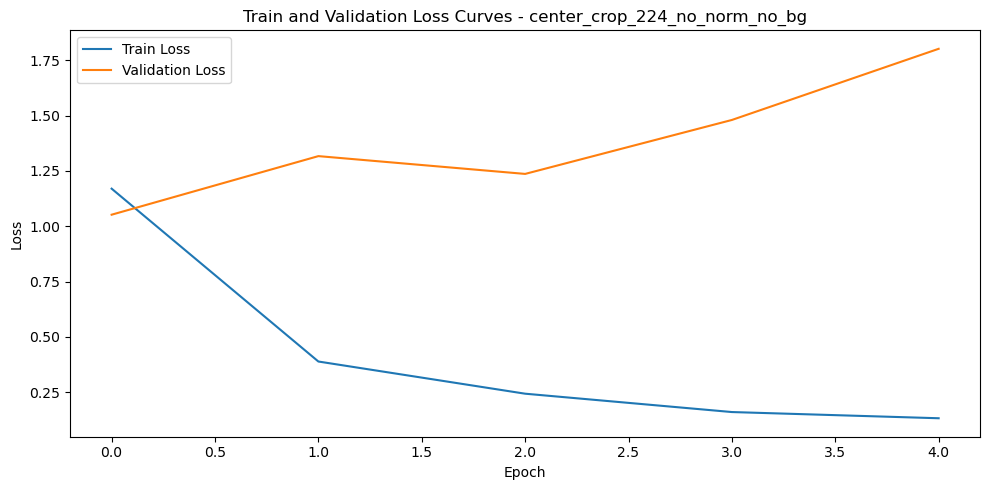

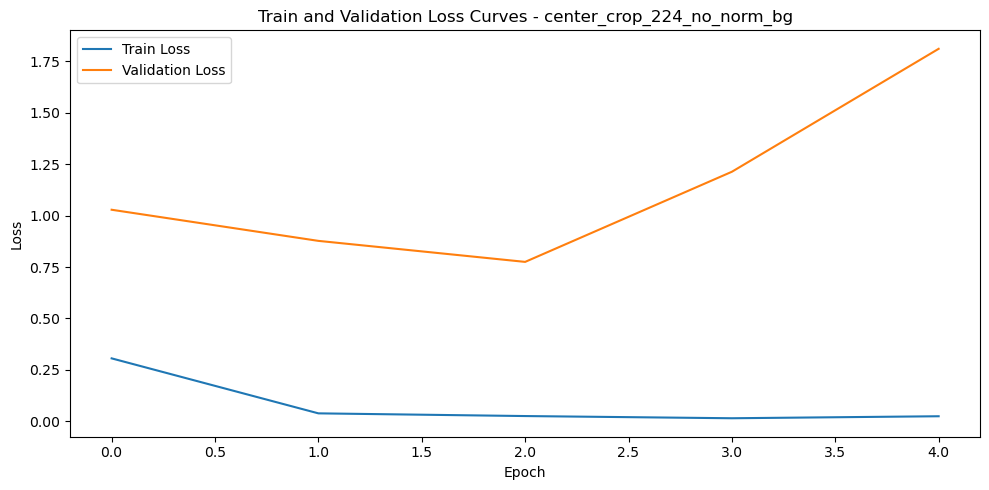

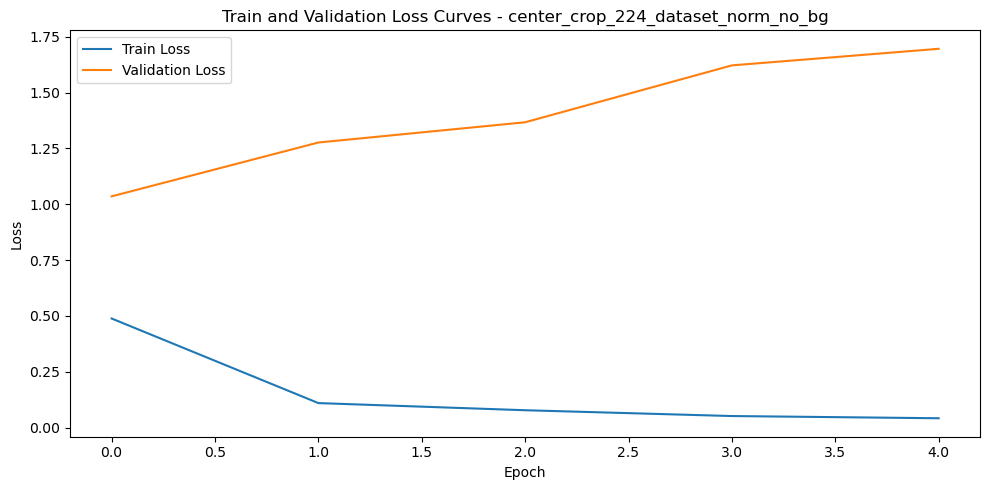

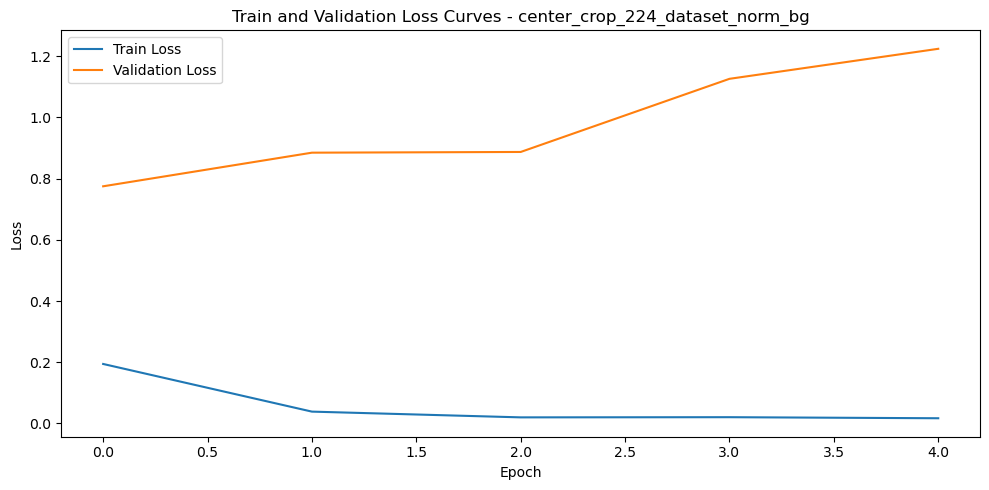

In [31]:
# For each fold, plot the train and validation loss curves across epochs (8 plots in total)
for i in range(len(histories)):
    # Get the history for the current fold
    history = histories[i]    
    # Create a Pandas DataFrame from the history dictionary
    history_df = pd.DataFrame(history)
    # Create a line plot of train and validation loss across epochs
    plt.figure(figsize=(10, 5))
    plt.plot(history_df['train_loss'], label='Train Loss')
    plt.plot(history_df['val_loss'], label='Validation Loss')
    # Configure, save and show the plot
    plt.title(f'Train and Validation Loss Curves - {titles[i]}')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend() 
    plt.tight_layout()
    plt.savefig(f'../results/test_data_configs/plots/loss_curves_{titles[i]}.png')
    plt.show()

### Evaluation

In [20]:
# Evaluate the model for each fold on the test set
results = []
for i in range(len(dataloaders)):
    model = models[i]
    result = eval_classifier(model=model, 
                            test_loader=dataloaders[i]['test'], 
                            target_label='object',
                            device=device)
    results.append(result)

Test Loss: 1.4031, Test Acc: 76.64%
Test Loss: 1.7840, Test Acc: 80.91%
Test Loss: 1.0067, Test Acc: 81.77%
Test Loss: 1.5599, Test Acc: 85.14%
Test Loss: 1.6772, Test Acc: 68.94%
Test Loss: 1.9346, Test Acc: 77.82%
Test Loss: 2.0895, Test Acc: 78.82%
Test Loss: 1.8827, Test Acc: 82.63%


In [21]:
# Print classification report for each fold
for i, result in enumerate(results):
    print(f'{titles[i]}:')
    print(classification_report(result['y_true'], 
                                result['y_pred'], 
                                target_names=object_labels))

pad_224_no_norm_no_bg:
              precision    recall  f1-score   support

       beans       0.65      0.60      0.62      1320
      hammer       0.72      0.87      0.79      1200
    pringles       0.74      0.71      0.72      1320
    scissors       0.76      0.55      0.64      1320
 tennis_ball       0.88      0.91      0.90      1320
 toilet_roll       0.82      0.98      0.89      1320

    accuracy                           0.77      7800
   macro avg       0.76      0.77      0.76      7800
weighted avg       0.76      0.77      0.76      7800

pad_224_no_norm_bg:
              precision    recall  f1-score   support

       beans       0.70      0.61      0.65      1320
      hammer       0.83      0.75      0.79      1200
    pringles       0.65      0.84      0.73      1320
    scissors       0.84      0.76      0.80      1320
 tennis_ball       0.90      0.90      0.90      1320
 toilet_roll       0.97      0.99      0.98      1320

    accuracy                      

In [22]:
# Convert test results to Pandas DataFrame
results_df = pd.DataFrame(results, index=titles)
# Save Dataframe to CSV file
results_df.to_csv('../results/test_data_configs/results.csv', index=True)

In [23]:
results_df

,test_loss,test_acc,y_true,y_pred
pad_224_no_norm_no_bg,1.403144,76.641026,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_no_norm_bg,1.784024,80.910256,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_dataset_norm_no_bg,1.006667,81.769231,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
pad_224_dataset_norm_bg,1.559855,85.141026,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_no_norm_no_bg,1.677232,68.935897,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_no_norm_bg,1.934585,77.820513,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_dataset_norm_no_bg,2.089529,78.820513,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
center_crop_224_dataset_norm_bg,1.882661,82.628205,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ...","[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [24]:
def plot_metrics(df, target_col, title):
    # Create a bar chart comparing the target metric for each data config
    df[[target_col]].plot(kind='bar', figsize=(12, 6))
    # Show titles with 'no_bg' in a different color
    for i, bar in enumerate(plt.gca().patches):
        if 'no_bg' in titles[i]:
            bar.set_color('orange')  
    # Configure, save and show the plot
    plt.title(f'{title} (orange bars indicate no_bg config)')
    plt.xlabel('Data Configuration')
    plt.ylabel(title)
    plt.xticks(rotation=45, ha='right')
    plt.legend().set_visible(False)  # Hide legend
    plt.tight_layout()
    plt.savefig(f'../results/test_data_configs/plots/{target_col}.png')
    plt.show()

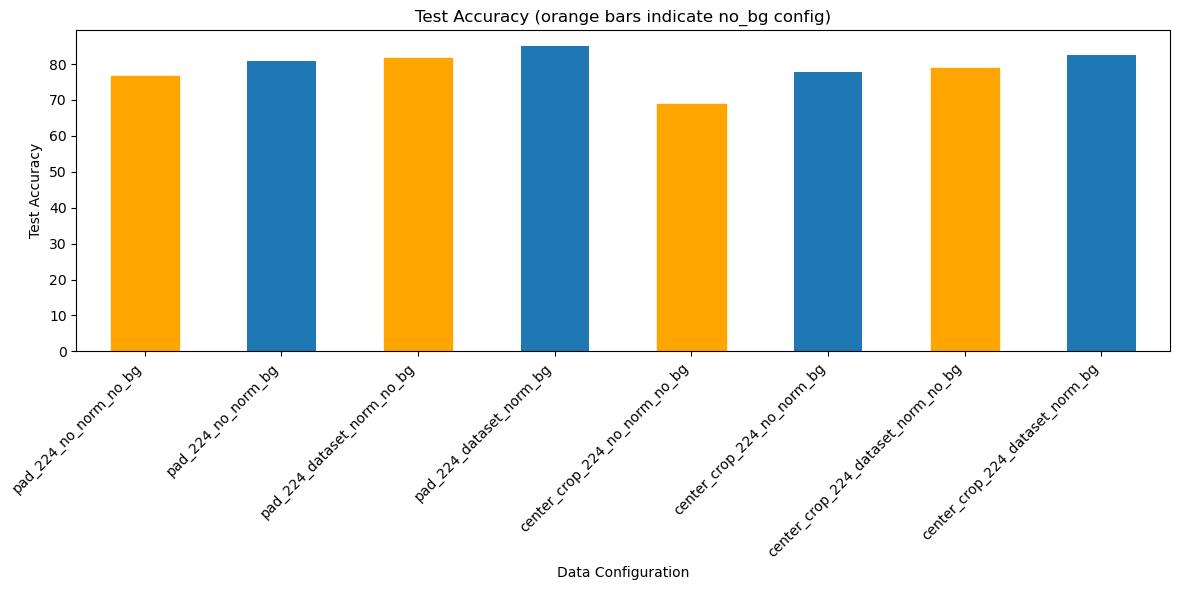

In [25]:
# Bar chart comparing the test accuracy for each fold
plot_metrics(results_df, 'test_acc', 'Test Accuracy')

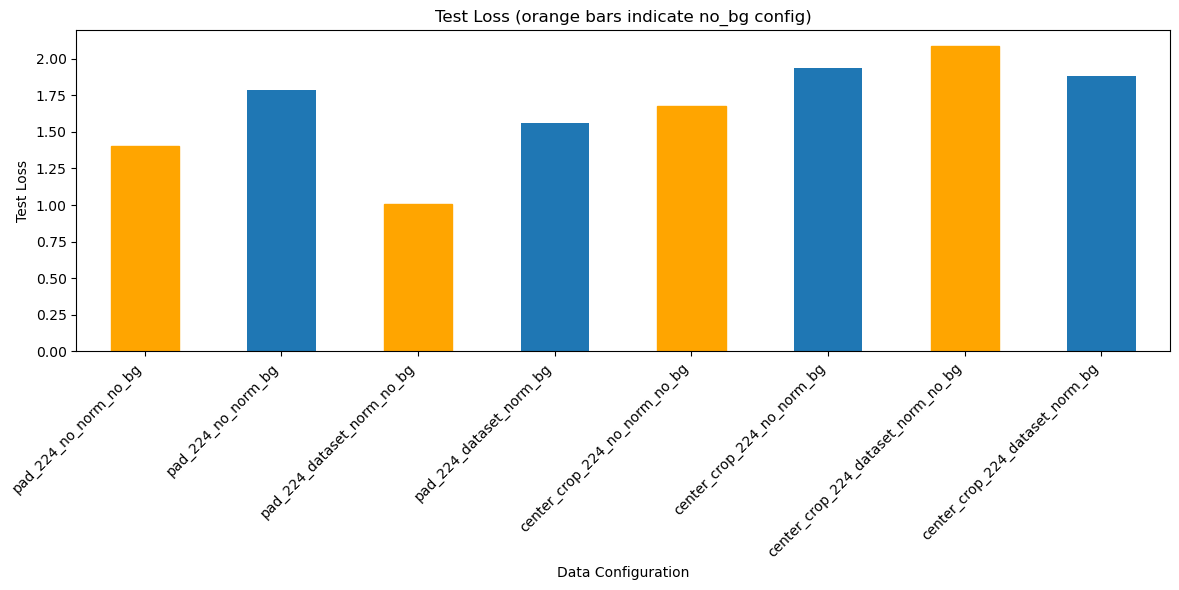

In [26]:
# Bar chart comparing the test loss for each fold
plot_metrics(results_df, 'test_loss', 'Test Loss')